In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
cancer_data = pd.read_csv("cancer_data_set.csv")

In [3]:
cancer_data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
cancer_data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  2
smoothness_mean            0
compactness_mean           1
concavity_mean             1
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     1
radius_se                  2
texture_se                 0
perimeter_se               0
area_se                    1
smoothness_se              0
compactness_se             0
concavity_se               1
concave points_se          2
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          1
concavity_worst            0
concave points_worst       0
symmetry_worst             2
fractal_dimension_worst    0
dtype: int64

In [5]:
cancer_data.dropna(inplace=True)

In [6]:
cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 556 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       556 non-null    int64  
 1   diagnosis                556 non-null    object 
 2   radius_mean              556 non-null    float64
 3   texture_mean             556 non-null    float64
 4   perimeter_mean           556 non-null    float64
 5   area_mean                556 non-null    float64
 6   smoothness_mean          556 non-null    float64
 7   compactness_mean         556 non-null    float64
 8   concavity_mean           556 non-null    float64
 9   concave points_mean      556 non-null    float64
 10  symmetry_mean            556 non-null    float64
 11  fractal_dimension_mean   556 non-null    float64
 12  radius_se                556 non-null    float64
 13  texture_se               556 non-null    float64
 14  perimeter_se             556 no

In [7]:
cancer_data.shape

(556, 32)

In [8]:
cancer_data.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [9]:
extra_data = cancer_data[['id', 'radius_mean']]

In [10]:
cancer_data = pd.merge(cancer_data, extra_data, on='id')

In [11]:
cancer_data.shape

(556, 33)

In [12]:
print(cancer_data.columns)
print(cancer_data.shape)  

Index(['id', 'diagnosis', 'radius_mean_x', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'radius_mean_y'],
      dtype='object')
(556, 33)


In [13]:
le = LabelEncoder()
cancer_data['diagnosis']=le.fit_transform(cancer_data['diagnosis'])

In [14]:
x = cancer_data.drop(columns=['diagnosis', 'id', 'radius_mean_y'])

In [15]:
y = cancer_data['diagnosis']

In [16]:
x.shape

(556, 30)

In [17]:
y.shape

(556,)

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.25)

In [19]:
x_train

,radius_mean_x,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
137,12.90,15.92,83.74,512.2,0.08677,0.09509,0.04894,0.03088,0.1778,0.06235,...,14.48,21.82,97.17,643.8,0.1312,0.2548,0.2090,0.1012,0.3549,0.08118
271,19.16,26.60,126.20,1138.0,0.10200,0.14530,0.19210,0.09664,0.1902,0.06220,...,23.72,35.90,159.80,1724.0,0.1782,0.3841,0.5754,0.1872,0.3258,0.09720
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
521,20.47,20.67,134.70,1299.0,0.09156,0.13130,0.15230,0.10150,0.2166,0.05419,...,23.23,27.15,152.00,1645.0,0.1097,0.2534,0.3092,0.1613,0.3220,0.06386
514,13.46,18.75,87.44,551.1,0.10750,0.11380,0.04201,0.03152,0.1723,0.06317,...,15.35,25.16,101.90,719.8,0.1624,0.3124,0.2654,0.1427,0.3518,0.08665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,17.20,24.52,114.20,929.4,0.10710,0.18300,0.16920,0.07944,0.1927,0.06487,...,23.32,33.82,151.60,1681.0,0.1585,0.7394,0.6566,0.1899,0.3313,0.13390
277,11.94,20.76,77.87,441.0,0.08605,0.10110,0.06574,0.03791,0.1588,0.06766,...,13.24,27.29,92.20,546.1,0.1116,0.2813,0.2365,0.1155,0.2465,0.09981
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750
359,21.71,17.25,140.90,1546.0,0.09384,0.08562,0.11680,0.08465,0.1717,0.05054,...,30.75,26.44,199.50,3143.0,0.1363,0.1628,0.2861,0.1820,0.2510,0.06494


In [20]:
x_train.shape

(417, 30)

In [21]:
y_train.shape

(417,)

In [22]:
x_test.shape

(139, 30)

In [23]:
y_test.shape

(139,)

In [24]:
 from sklearn.tree import DecisionTreeClassifier

In [25]:
classifier=DecisionTreeClassifier(random_state=0)

In [26]:
classifier.fit(x_train,y_train)

DecisionTreeClassifier(random_state=0)

In [27]:
classifier.fit(x_train, y_train)

DecisionTreeClassifier(random_state=0)

In [28]:
y_pred = classifier.predict(x_test)

In [29]:
y_pred2 = classifier.predict(x_train)


In [30]:
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score
from sklearn.metrics import classification_report

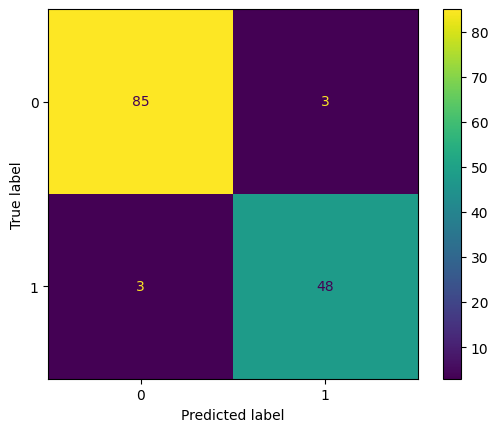

In [31]:
cm = ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

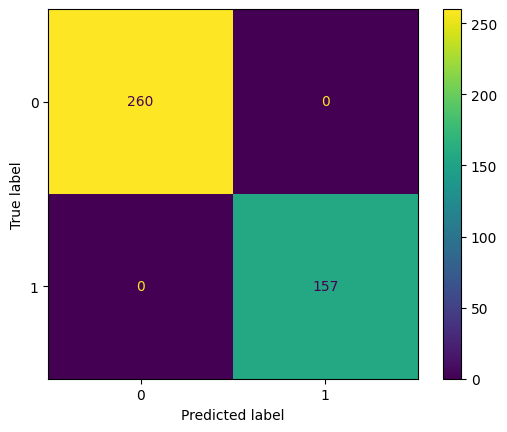

In [32]:
cm2 = ConfusionMatrixDisplay.from_predictions(y_train,y_pred2)

In [33]:
accuracy_score(y_train, y_pred2)

1.0

In [34]:
cm

In [35]:
accuracy_score(y_test,y_pred)

0.9568345323741008

In [36]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        88
           1       0.94      0.94      0.94        51

    accuracy                           0.96       139
   macro avg       0.95      0.95      0.95       139
weighted avg       0.96      0.96      0.96       139



In [37]:
from sklearn.tree import plot_tree

<Figure size 640x480 with 0 Axes>

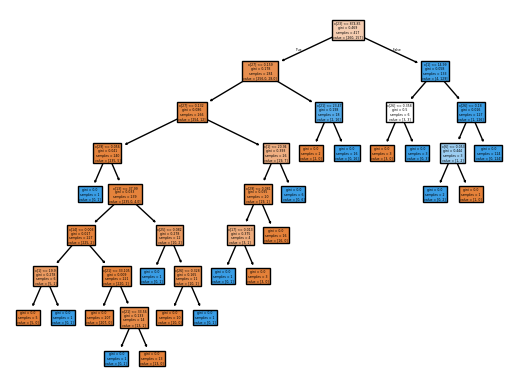

<Figure size 640x480 with 0 Axes>

In [38]:
plot_tree(classifier,filled=True)
plt.figure()

In [39]:
x_values = pd.DataFrame([[20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902]])
prediction = classifier.predict(x_values)
prediction

if prediction[0] == 1:
    print("Diagnosis : M");
else:
    print("Diagnosis : B");

Diagnosis : M


C:\Users\madhu\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [40]:
x_train.dtypes

radius_mean_x              float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst       float64
symmetry_worst      

In [41]:
x_train.shape

(417, 30)

In [42]:
#here row number
x_values = pd.DataFrame([[17.99, 10.38, 122.8,1001, 0.1184, 0.2776, 0.3001,0.1471,0.2419	0.07871	1.095	0.9053	8.589	153.4	0.006399	0.04904	0.05373	0.01587	0.03003	0.006193	25.38	17.33	184.6	2019	0.1622	0.6656	0.7119	0.2654	0.4601	0.1189]])
prediction = classifier.predict(x_values)


if prediction[0] == 1:
    print("Diagnosis : Malignant"); #0 = B, 1 = M
else:
    print("Diagnosis : benign");

SyntaxError: invalid syntax. Perhaps you forgot a comma? (444555477.py, line 2)

In [ ]:
prediction